In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import lightgbm as lgb  

print("Libraries imported successfully!")

Libraries imported successfully!


In [45]:
import numpy as np

# Define path for new features
feature_path_new = "C:\\DatePalmDisease\\ml_new\\"

# Load new GLCM dataset (Texture Only)
X_train_glcm_new = np.load(feature_path_new + "X_train_glcm.npy")
X_test_glcm_new = np.load(feature_path_new + "X_test_glcm.npy")
y_train_glcm_new = np.load(feature_path_new + "y_train_glcm.npy").ravel()
y_test_glcm_new = np.load(feature_path_new + "y_test_glcm.npy").ravel()

# Load new GLCM + HSV dataset (Texture + Color)
X_train_glcm_hsv_new = np.load(feature_path_new + "X_train_glcm_hsv.npy")
X_test_glcm_hsv_new = np.load(feature_path_new + "X_test_glcm_hsv.npy")
y_train_glcm_hsv_new = np.load(feature_path_new + "y_train_glcm_hsv.npy").ravel()
y_test_glcm_hsv_new = np.load(feature_path_new + "y_test_glcm_hsv.npy").ravel()

# Print dataset shapes
print("\n New GLCM Dataset (Texture Only):")
print(f"  X_train_glcm_new: {X_train_glcm_new.shape} | y_train_glcm_new: {y_train_glcm_new.shape}")
print(f"  X_test_glcm_new: {X_test_glcm_new.shape} | y_test_glcm_new: {y_test_glcm_new.shape}")

print("\n New GLCM + HSV Dataset (Texture + Color):")
print(f"  X_train_glcm_hsv_new: {X_train_glcm_hsv_new.shape} | y_train_glcm_hsv_new: {y_train_glcm_hsv_new.shape}")
print(f"  X_test_glcm_hsv_new: {X_test_glcm_hsv_new.shape} | y_test_glcm_hsv_new: {y_test_glcm_hsv_new.shape}")



 New GLCM Dataset (Texture Only):
  X_train_glcm_new: (2865, 80) | y_train_glcm_new: (2865,)
  X_test_glcm_new: (717, 80) | y_test_glcm_new: (717,)

 New GLCM + HSV Dataset (Texture + Color):
  X_train_glcm_hsv_new: (2865, 86) | y_train_glcm_hsv_new: (2865,)
  X_test_glcm_hsv_new: (717, 86) | y_test_glcm_hsv_new: (717,)


In [47]:
import numpy as np

# Define base path for new extracted features
base_path = "C:\\DatePalmDisease\\ml_new\\"

# Load New GLCM dataset (Texture Only)
X_train_glcm_new = np.load(base_path + "X_train_glcm.npy")
X_test_glcm_new = np.load(base_path + "X_test_glcm.npy")
y_train_glcm_new = np.load(base_path + "y_train_glcm.npy").ravel()
y_test_glcm_new = np.load(base_path + "y_test_glcm.npy").ravel()

# Load New GLCM+HSV dataset (Texture + Color)
X_train_glcm_hsv_new = np.load(base_path + "X_train_glcm_hsv.npy")
X_test_glcm_hsv_new = np.load(base_path + "X_test_glcm_hsv.npy")
y_train_glcm_hsv_new = np.load(base_path + "y_train_glcm_hsv.npy").ravel()
y_test_glcm_hsv_new = np.load(base_path + "y_test_glcm_hsv.npy").ravel()

# Display Train-Test Split Information
print("\n New GLCM Feature Set:")
print(f"  Training Samples: {X_train_glcm_new.shape[0]}  |  Testing Samples: {X_test_glcm_new.shape[0]}")
print(f"  Feature Size: {X_train_glcm_new.shape[1]}  |  Classes: {len(np.unique(y_train_glcm_new))}")

print("\n New GLCM+HSV Feature Set:")
print(f"  Training Samples: {X_train_glcm_hsv_new.shape[0]}  |  Testing Samples: {X_test_glcm_hsv_new.shape[0]}")
print(f"  Feature Size: {X_train_glcm_hsv_new.shape[1]}  |  Classes: {len(np.unique(y_train_glcm_hsv_new))}")

print("\n New Train-Test Splitting Completed!")



 New GLCM Feature Set:
  Training Samples: 2865  |  Testing Samples: 717
  Feature Size: 80  |  Classes: 3

 New GLCM+HSV Feature Set:
  Training Samples: 2865  |  Testing Samples: 717
  Feature Size: 86  |  Classes: 3

 New Train-Test Splitting Completed!


# ML Model

In [49]:
import numpy as np
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

feature_path_new = "C:\\DatePalmDisease\\ml_new\\"

X_train_glcm_new = np.load(feature_path_new + "X_train_glcm.npy")
X_test_glcm_new = np.load(feature_path_new + "X_test_glcm.npy")
y_train_glcm_new = np.load(feature_path_new + "y_train_glcm.npy").ravel()
y_test_glcm_new = np.load(feature_path_new + "y_test_glcm.npy").ravel()

X_train_glcm_hsv_new = np.load(feature_path_new + "X_train_glcm_hsv.npy")
X_test_glcm_hsv_new = np.load(feature_path_new + "X_test_glcm_hsv.npy")
y_train_glcm_hsv_new = np.load(feature_path_new + "y_train_glcm_hsv.npy").ravel()
y_test_glcm_hsv_new = np.load(feature_path_new + "y_test_glcm_hsv.npy").ravel()

scaler = MinMaxScaler()
X_train_glcm_new = scaler.fit_transform(X_train_glcm_new)
X_test_glcm_new = scaler.transform(X_test_glcm_new)  # Added this line

X_train_glcm_hsv_new = scaler.fit_transform(X_train_glcm_hsv_new)
X_test_glcm_hsv_new = scaler.transform(X_test_glcm_hsv_new)  # Added this line

joblib.dump(scaler, feature_path_new + "scaler_minmax.pkl")
print(" MinMaxScaler saved successfully!")

print(" Training SVM with Grid Search (GLCM Features)...")
svm_params = {"C": [0.1, 1, 10, 100], "kernel": ["linear", "rbf"]}
svm_glcm = GridSearchCV(SVC(probability=True), svm_params, cv=5, scoring="accuracy", n_jobs=-1)
svm_glcm.fit(X_train_glcm_new, y_train_glcm_new)
joblib.dump(svm_glcm.best_estimator_, feature_path_new + "SVM_GLCM_New.pkl")
print(f" Best SVM Parameters (GLCM): {svm_glcm.best_params_}")

print(" Training SVM with Grid Search (GLCM+HSV Features)...")
svm_glcm_hsv = GridSearchCV(SVC(probability=True), svm_params, cv=5, scoring="accuracy", n_jobs=-1)
svm_glcm_hsv.fit(X_train_glcm_hsv_new, y_train_glcm_hsv_new)
joblib.dump(svm_glcm_hsv.best_estimator_, feature_path_new + "SVM_GLCM_HSV_New.pkl")
print(f" Best SVM Parameters (GLCM+HSV): {svm_glcm_hsv.best_params_}")

print(" Training KNN with Grid Search (GLCM Features)...")
knn_params = {"n_neighbors": [3, 5, 7]}
knn_glcm = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring="accuracy", n_jobs=-1)
knn_glcm.fit(X_train_glcm_new, y_train_glcm_new)
joblib.dump(knn_glcm.best_estimator_, feature_path_new + "KNN_GLCM_New.pkl")
print(f" Best KNN Parameters (GLCM): {knn_glcm.best_params_}")

print(" Training KNN with Grid Search (GLCM+HSV Features)...")
knn_glcm_hsv = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring="accuracy", n_jobs=-1)
knn_glcm_hsv.fit(X_train_glcm_hsv_new, y_train_glcm_hsv_new)
joblib.dump(knn_glcm_hsv.best_estimator_, feature_path_new + "KNN_GLCM_HSV_New.pkl")
print(f" Best KNN Parameters (GLCM+HSV): {knn_glcm_hsv.best_params_}")

print(" Training Random Forest with Grid Search (GLCM Features)...")
rf_params = {"n_estimators": [50, 100, 200]}
rf_glcm = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring="accuracy", n_jobs=-1)
rf_glcm.fit(X_train_glcm_new, y_train_glcm_new)
joblib.dump(rf_glcm.best_estimator_, feature_path_new + "RF_GLCM_New.pkl")
print(f"Best RF Parameters (GLCM): {rf_glcm.best_params_}")

print("Training Random Forest with Grid Search (GLCM+HSV Features)...")
rf_glcm_hsv = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring="accuracy", n_jobs=-1)
rf_glcm_hsv.fit(X_train_glcm_hsv_new, y_train_glcm_hsv_new)
joblib.dump(rf_glcm_hsv.best_estimator_, feature_path_new + "RF_GLCM_HSV_New.pkl")
print(f" Best RF Parameters (GLCM+HSV): {rf_glcm_hsv.best_params_}")

print(" Training LightGBM (GLCM Features)...")
lgbm_glcm = LGBMClassifier(n_estimators=200, verbosity=-1)
lgbm_glcm.fit(X_train_glcm_new, y_train_glcm_new)
joblib.dump(lgbm_glcm, feature_path_new + "LGBM_GLCM_New.pkl")
print(" LightGBM (GLCM) Trained!")

print(" Training LightGBM (GLCM+HSV Features)...")
lgbm_glcm_hsv = LGBMClassifier(n_estimators=200, verbosity=-1)
lgbm_glcm_hsv.fit(X_train_glcm_hsv_new, y_train_glcm_hsv_new)
joblib.dump(lgbm_glcm_hsv, feature_path_new + "LGBM_GLCM_HSV_New.pkl")
print(" LightGBM (GLCM+HSV) Trained!")

print("\n All ML models trained and saved successfully!")


 MinMaxScaler saved successfully!
 Training SVM with Grid Search (GLCM Features)...
 Best SVM Parameters (GLCM): {'C': 100, 'kernel': 'rbf'}
 Training SVM with Grid Search (GLCM+HSV Features)...
 Best SVM Parameters (GLCM+HSV): {'C': 100, 'kernel': 'rbf'}
 Training KNN with Grid Search (GLCM Features)...
 Best KNN Parameters (GLCM): {'n_neighbors': 3}
 Training KNN with Grid Search (GLCM+HSV Features)...
 Best KNN Parameters (GLCM+HSV): {'n_neighbors': 3}
 Training Random Forest with Grid Search (GLCM Features)...
Best RF Parameters (GLCM): {'n_estimators': 100}
Training Random Forest with Grid Search (GLCM+HSV Features)...
 Best RF Parameters (GLCM+HSV): {'n_estimators': 200}
 Training LightGBM (GLCM Features)...
 LightGBM (GLCM) Trained!
 Training LightGBM (GLCM+HSV Features)...
 LightGBM (GLCM+HSV) Trained!

 All ML models trained and saved successfully!



SVM GLCM Features    Accuracy: 0.9303
SVM GLCM+HSV Features Accuracy: 0.9874

                SVM GLCM Features                                        SVM GLCM+HSV Features                      


              precision    recall  f1-score   support               precision    recall  f1-score   support
                                                                                                     
           0     0.9867    0.9530    0.9696       234            0     1.0000    0.9957    0.9979       234
           1     0.8509    0.9710    0.9070       241            1     0.9793    0.9834    0.9814       241
           2     0.9722    0.8678    0.9170       242            2     0.9835    0.9835    0.9835       242
                                                                                                     
    accuracy                         0.9303       717     accuracy                         0.9874       717
   macro avg     0.9366    0.9306    0.9312       717    m

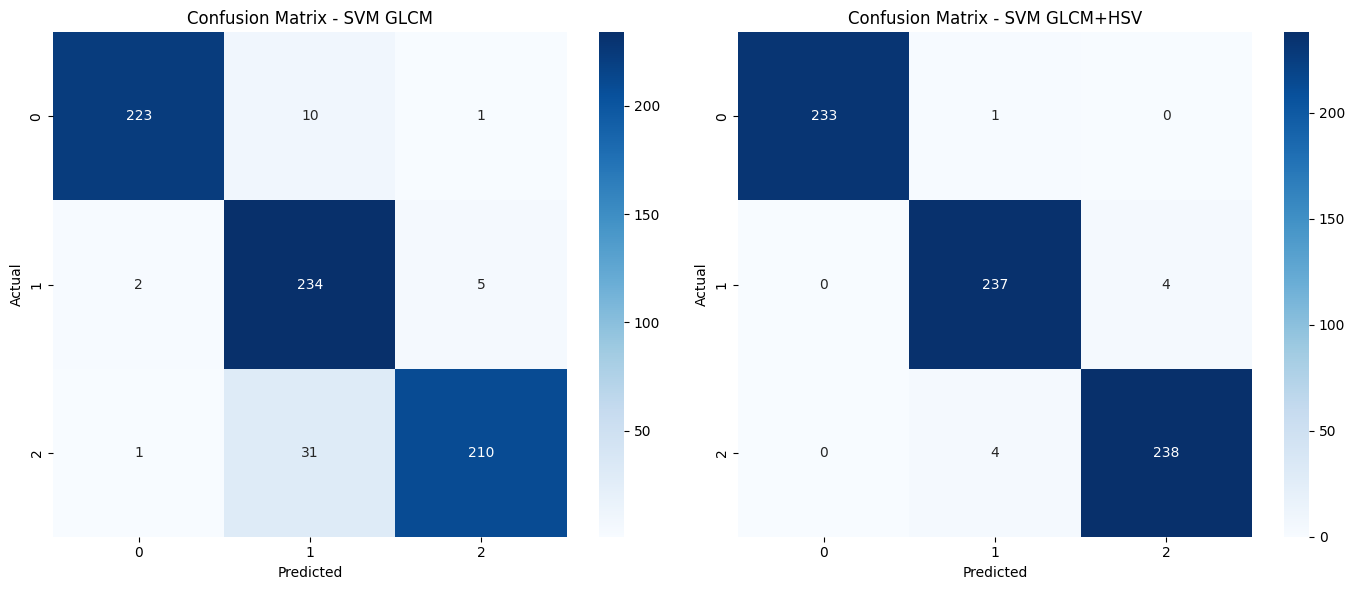

In [51]:
#SVM
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

feature_path_new = "C:\\DatePalmDisease\\ml_new\\"

X_test_glcm_new = np.load(feature_path_new + "X_test_glcm.npy")
y_test_glcm_new = np.load(feature_path_new + "y_test_glcm.npy").ravel()

X_test_glcm_hsv_new = np.load(feature_path_new + "X_test_glcm_hsv.npy")
y_test_glcm_hsv_new = np.load(feature_path_new + "y_test_glcm_hsv.npy").ravel()

scaler_glcm = joblib.load(feature_path_new + "scaler_glcm.pkl")
scaler_glcm_hsv = joblib.load(feature_path_new + "scaler_glcm_hsv.pkl")

X_test_glcm_new = scaler_glcm.transform(X_test_glcm_new)  
X_test_glcm_hsv_new = scaler_glcm_hsv.transform(X_test_glcm_hsv_new)  


svm_glcm_model = joblib.load(feature_path_new + "SVM_GLCM_New.pkl")
svm_glcm_hsv_model = joblib.load(feature_path_new + "SVM_GLCM_HSV_New.pkl")

y_pred_glcm = svm_glcm_model.predict(X_test_glcm_new)
y_pred_glcm_hsv = svm_glcm_hsv_model.predict(X_test_glcm_hsv_new)

acc_glcm = accuracy_score(y_test_glcm_new, y_pred_glcm)
acc_glcm_hsv = accuracy_score(y_test_glcm_hsv_new, y_pred_glcm_hsv)

print("\nSVM GLCM Features    Accuracy: {:.4f}".format(acc_glcm))
print("SVM GLCM+HSV Features Accuracy: {:.4f}\n".format(acc_glcm_hsv))

report_glcm = classification_report(y_test_glcm_new, y_pred_glcm, digits=4)
report_glcm_hsv = classification_report(y_test_glcm_hsv_new, y_pred_glcm_hsv, digits=4)

print(f"{'SVM GLCM Features':^50} {'SVM GLCM+HSV Features':^65}")
print("\n")

lines_glcm = report_glcm.split("\n")
lines_glcm_hsv = report_glcm_hsv.split("\n")

for line1, line2 in zip(lines_glcm, lines_glcm_hsv):
    print(f"{line1:<50} {line2:<50}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_glcm = confusion_matrix(y_test_glcm_new, y_pred_glcm)
cm_glcm_hsv = confusion_matrix(y_test_glcm_hsv_new, y_pred_glcm_hsv)

sns.heatmap(cm_glcm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_test_glcm_new), yticklabels=set(y_test_glcm_new), ax=axes[0])
axes[0].set_title("Confusion Matrix - SVM GLCM")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_glcm_hsv, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_test_glcm_hsv_new), yticklabels=set(y_test_glcm_hsv_new), ax=axes[1])
axes[1].set_title("Confusion Matrix - SVM GLCM+HSV")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


KNN (GLCM Features)      : 0.9093
KNN (GLCM+HSV Features)  : 0.9735


                SVM GLCM Features                                        SVM GLCM+HSV Features                      


              precision    recall  f1-score   support               precision    recall  f1-score   support
                                         
           0     0.9530    0.9530    0.9530       234            0     0.9787    0.9829    0.9808       234
           1     0.8661    0.9129    0.8889       241            1     0.9631    0.9751    0.9691       241
           2     0.9127    0.8636    0.8875       242            2     0.9790    0.9628    0.9708       242
                                         
    accuracy                         0.9093       717     accuracy                         0.9735       717
   macro avg     0.9106    0.9098    0.9098       717    macro avg     0.9736    0.9736    0.9736       717
weighted avg     0.9102    0.9093    0.9093       717 weighted avg     0.9736  

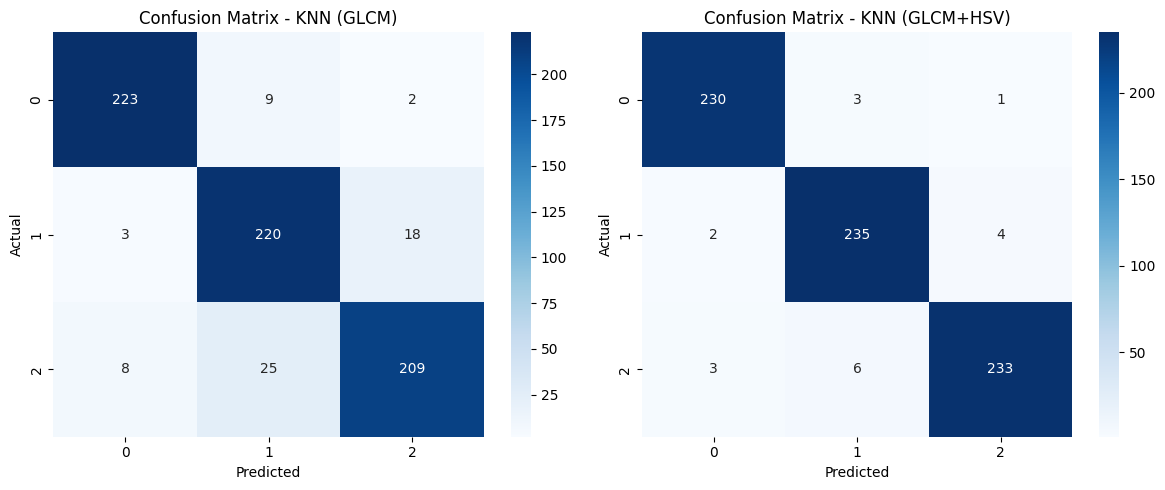

In [53]:
#KNN
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

feature_path_new = "C:\\DatePalmDisease\\ml_new\\"

X_test_glcm_new = np.load(feature_path_new + "X_test_glcm.npy")
y_test_glcm_new = np.load(feature_path_new + "y_test_glcm.npy").ravel()

X_test_glcm_hsv_new = np.load(feature_path_new + "X_test_glcm_hsv.npy")
y_test_glcm_hsv_new = np.load(feature_path_new + "y_test_glcm_hsv.npy").ravel()

scaler_glcm = joblib.load(feature_path_new + "scaler_glcm.pkl")
scaler_glcm_hsv = joblib.load(feature_path_new + "scaler_glcm_hsv.pkl")

X_test_glcm_new = scaler_glcm.transform(X_test_glcm_new)  
X_test_glcm_hsv_new = scaler_glcm_hsv.transform(X_test_glcm_hsv_new)  

knn_glcm_model = joblib.load(feature_path_new + "KNN_GLCM_New.pkl")
knn_glcm_hsv_model = joblib.load(feature_path_new + "KNN_GLCM_HSV_New.pkl")

y_pred_glcm = knn_glcm_model.predict(X_test_glcm_new)
y_pred_glcm_hsv = knn_glcm_hsv_model.predict(X_test_glcm_hsv_new)

acc_glcm = accuracy_score(y_test_glcm_new, y_pred_glcm)
acc_glcm_hsv = accuracy_score(y_test_glcm_hsv_new, y_pred_glcm_hsv)

print(f"KNN (GLCM Features)      : {acc_glcm:.4f}")
print(f"KNN (GLCM+HSV Features)  : {acc_glcm_hsv:.4f}")

report_glcm = classification_report(y_test_glcm_new, y_pred_glcm, digits=4)
report_glcm_hsv = classification_report(y_test_glcm_hsv_new, y_pred_glcm_hsv, digits=4)
print("\n")
print(f"{'SVM GLCM Features':^50} {'SVM GLCM+HSV Features':^65}")
print("\n")
lines_glcm = report_glcm.split("\n")
lines_glcm_hsv = report_glcm_hsv.split("\n")

for line1, line2 in zip(lines_glcm, lines_glcm_hsv):
    print(f"{line1:<40} {line2}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_glcm = confusion_matrix(y_test_glcm_new, y_pred_glcm)
cm_glcm_hsv = confusion_matrix(y_test_glcm_hsv_new, y_pred_glcm_hsv)

sns.heatmap(cm_glcm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_test_glcm_new), yticklabels=set(y_test_glcm_new), ax=axes[0])
axes[0].set_title("Confusion Matrix - KNN (GLCM)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_glcm_hsv, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_test_glcm_hsv_new), yticklabels=set(y_test_glcm_hsv_new), ax=axes[1])
axes[1].set_title("Confusion Matrix - KNN (GLCM+HSV)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


RF (GLCM Features)      : 0.8870
RF (GLCM+HSV Features)  : 0.9456


                SVM GLCM Features                                        SVM GLCM+HSV Features                      


              precision    recall  f1-score   support               precision    recall  f1-score   support
                                         
           0     0.9301    0.9103    0.9201       234            0     0.9778    0.9402    0.9586       234
           1     0.8043    0.9378    0.8659       241            1     0.8872    0.9793    0.9310       241
           2     0.9517    0.8140    0.8775       242            2     0.9823    0.9174    0.9487       242
                                         
    accuracy                         0.8870       717     accuracy                         0.9456       717
   macro avg     0.8954    0.8874    0.8878       717    macro avg     0.9491    0.9456    0.9461       717
weighted avg     0.8951    0.8870    0.8875       717 weighted avg     0.9489    

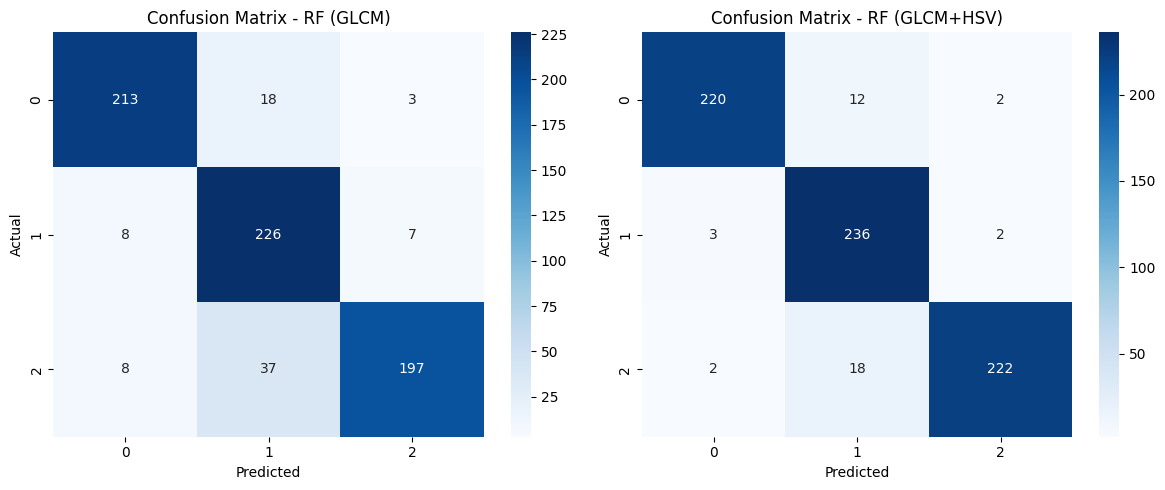

In [55]:
#RABDOM FOREST
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

feature_path_new = "C:\\DatePalmDisease\\ml_new\\"

X_test_glcm_new = np.load(feature_path_new + "X_test_glcm.npy")
y_test_glcm_new = np.load(feature_path_new + "y_test_glcm.npy").ravel()

X_test_glcm_hsv_new = np.load(feature_path_new + "X_test_glcm_hsv.npy")
y_test_glcm_hsv_new = np.load(feature_path_new + "y_test_glcm_hsv.npy").ravel()

scaler_glcm = joblib.load(feature_path_new + "scaler_glcm.pkl")
scaler_glcm_hsv = joblib.load(feature_path_new + "scaler_glcm_hsv.pkl")

X_test_glcm_new = scaler_glcm.transform(X_test_glcm_new)  
X_test_glcm_hsv_new = scaler_glcm_hsv.transform(X_test_glcm_hsv_new)  

rf_glcm_model = joblib.load(feature_path_new + "RF_GLCM_New.pkl")
rf_glcm_hsv_model = joblib.load(feature_path_new + "RF_GLCM_HSV_New.pkl")

y_pred_glcm = rf_glcm_model.predict(X_test_glcm_new)
y_pred_glcm_hsv = rf_glcm_hsv_model.predict(X_test_glcm_hsv_new)

acc_glcm = accuracy_score(y_test_glcm_new, y_pred_glcm)
acc_glcm_hsv = accuracy_score(y_test_glcm_hsv_new, y_pred_glcm_hsv)

print(f"RF (GLCM Features)      : {acc_glcm:.4f}")
print(f"RF (GLCM+HSV Features)  : {acc_glcm_hsv:.4f}")

report_glcm = classification_report(y_test_glcm_new, y_pred_glcm, digits=4)
report_glcm_hsv = classification_report(y_test_glcm_hsv_new, y_pred_glcm_hsv, digits=4)
print("\n")
print(f"{'SVM GLCM Features':^50} {'SVM GLCM+HSV Features':^65}")
print("\n")

lines_glcm = report_glcm.split("\n")
lines_glcm_hsv = report_glcm_hsv.split("\n")

for line1, line2 in zip(lines_glcm, lines_glcm_hsv):
    print(f"{line1:<40} {line2}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_glcm = confusion_matrix(y_test_glcm_new, y_pred_glcm)
cm_glcm_hsv = confusion_matrix(y_test_glcm_hsv_new, y_pred_glcm_hsv)

sns.heatmap(cm_glcm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_test_glcm_new), yticklabels=set(y_test_glcm_new), ax=axes[0])
axes[0].set_title("Confusion Matrix - RF (GLCM)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_glcm_hsv, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_test_glcm_hsv_new), yticklabels=set(y_test_glcm_hsv_new), ax=axes[1])
axes[1].set_title("Confusion Matrix - RF (GLCM+HSV)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


LGBM (GLCM Features)      : 0.9358
LGBM (GLCM+HSV Features)  : 0.9707


                SVM GLCM Features                                        SVM GLCM+HSV Features                      


              precision    recall  f1-score   support               precision    recall  f1-score   support
                                         
           0     0.9643    0.9231    0.9432       234            0     0.9580    0.9744    0.9661       234
           1     0.8830    0.9710    0.9249       241            1     0.9746    0.9544    0.9644       241
           2     0.9693    0.9132    0.9404       242            2     0.9794    0.9835    0.9814       242
                                         
    accuracy                         0.9358       717     accuracy                         0.9707       717
   macro avg     0.9389    0.9358    0.9362       717    macro avg     0.9707    0.9707    0.9706       717
weighted avg     0.9387    0.9358    0.9361       717 weighted avg     0.9708

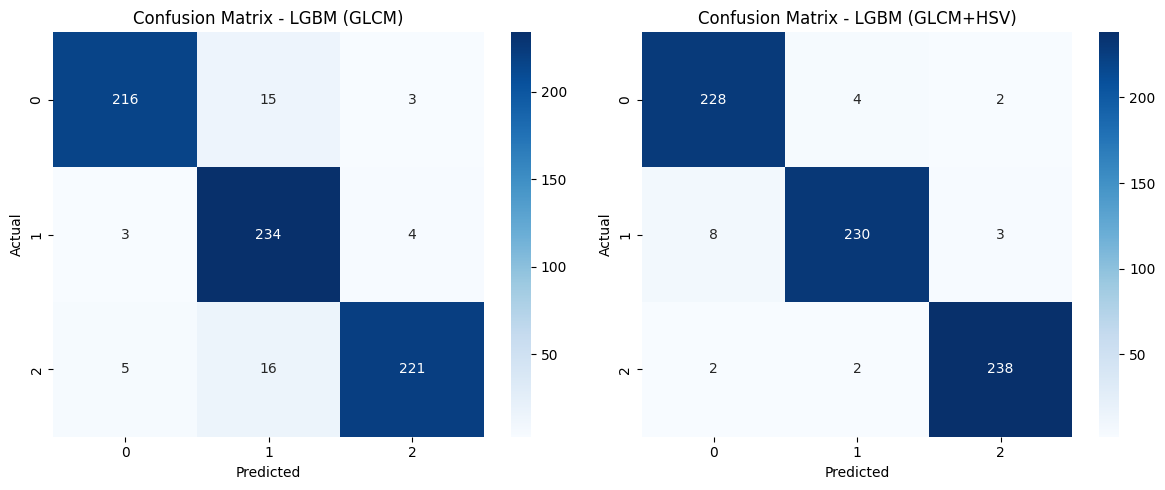

In [57]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")

feature_path_new = "C:\\DatePalmDisease\\ml_new\\"

X_test_glcm_new = np.load(feature_path_new + "X_test_glcm.npy")
y_test_glcm_new = np.load(feature_path_new + "y_test_glcm.npy").ravel()

X_test_glcm_hsv_new = np.load(feature_path_new + "X_test_glcm_hsv.npy")
y_test_glcm_hsv_new = np.load(feature_path_new + "y_test_glcm_hsv.npy").ravel()

scaler_glcm = joblib.load(feature_path_new + "scaler_glcm.pkl")
scaler_glcm_hsv = joblib.load(feature_path_new + "scaler_glcm_hsv.pkl")

X_test_glcm_new = scaler_glcm.transform(X_test_glcm_new)  
X_test_glcm_hsv_new = scaler_glcm_hsv.transform(X_test_glcm_hsv_new)  

lgbm_glcm_model = joblib.load(feature_path_new + "LGBM_GLCM_New.pkl")
lgbm_glcm_hsv_model = joblib.load(feature_path_new + "LGBM_GLCM_HSV_New.pkl")

y_pred_glcm = lgbm_glcm_model.predict(X_test_glcm_new)
y_pred_glcm_hsv = lgbm_glcm_hsv_model.predict(X_test_glcm_hsv_new)

acc_glcm = accuracy_score(y_test_glcm_new, y_pred_glcm)
acc_glcm_hsv = accuracy_score(y_test_glcm_hsv_new, y_pred_glcm_hsv)

print(f"LGBM (GLCM Features)      : {acc_glcm:.4f}")
print(f"LGBM (GLCM+HSV Features)  : {acc_glcm_hsv:.4f}")

report_glcm = classification_report(y_test_glcm_new, y_pred_glcm, digits=4)
report_glcm_hsv = classification_report(y_test_glcm_hsv_new, y_pred_glcm_hsv, digits=4)
print("\n")
print(f"{'SVM GLCM Features':^50} {'SVM GLCM+HSV Features':^65}")
print("\n")

lines_glcm = report_glcm.split("\n")
lines_glcm_hsv = report_glcm_hsv.split("\n")

for line1, line2 in zip(lines_glcm, lines_glcm_hsv):
    print(f"{line1:<40} {line2}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_glcm = confusion_matrix(y_test_glcm_new, y_pred_glcm)
cm_glcm_hsv = confusion_matrix(y_test_glcm_hsv_new, y_pred_glcm_hsv)

sns.heatmap(cm_glcm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_test_glcm_new), yticklabels=set(y_test_glcm_new), ax=axes[0])
axes[0].set_title("Confusion Matrix - LGBM (GLCM)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_glcm_hsv, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_test_glcm_hsv_new), yticklabels=set(y_test_glcm_hsv_new), ax=axes[1])
axes[1].set_title("Confusion Matrix - LGBM (GLCM+HSV)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


Model metrics comparison saved to: C:\DatePalmDisease\ml_new\ML_Comparison.csv

Model Metrics Comparison:
               Accuracy  Precision    Recall  F1-Score
SVM_GLCM       0.930265   0.936179  0.930265  0.930796
SVM_GLCM_HSV   0.987448   0.987477  0.987448  0.987459
KNN_GLCM       0.909344   0.910188  0.909344  0.909332
KNN_GLCM_HSV   0.973501   0.973568  0.973501  0.973497
RF_GLCM        0.887029   0.895103  0.887029  0.887501
RF_GLCM_HSV    0.945607   0.948865  0.945607  0.945978
LGBM_GLCM      0.935844   0.938662  0.935844  0.936123
LGBM_GLCM_HSV  0.970711   0.970797  0.970711  0.970695


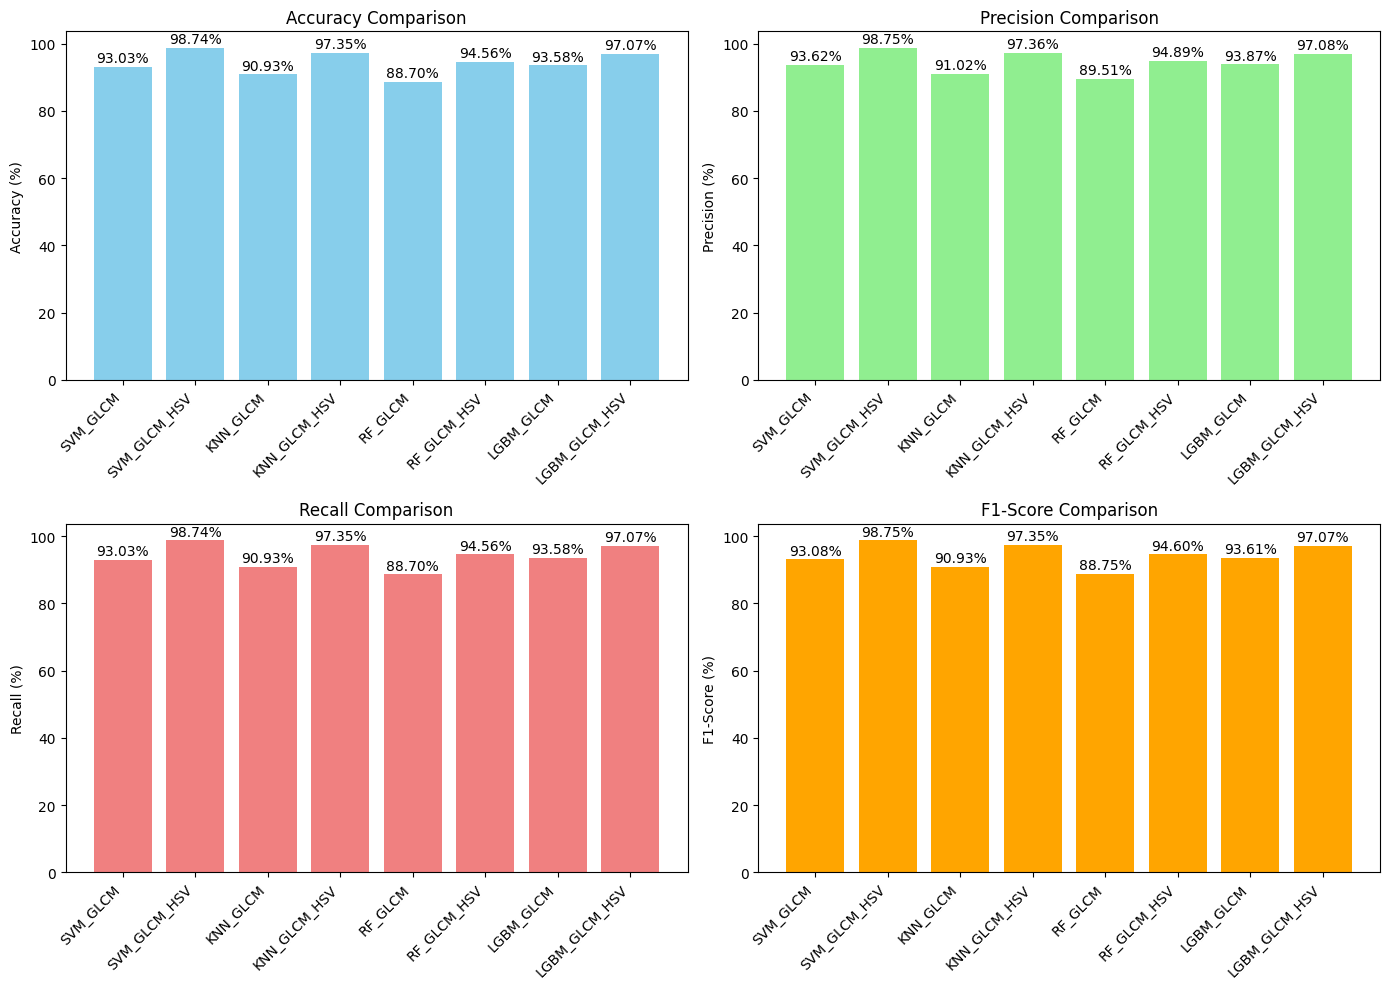

In [15]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Path to saved models and test data
feature_path_new = "C:\\DatePalmDisease\\ml_new\\"

# Load test datasets
X_test_glcm = np.load(feature_path_new + "X_test_glcm.npy")
y_test_glcm = np.load(feature_path_new + "y_test_glcm.npy").ravel()

X_test_glcm_hsv = np.load(feature_path_new + "X_test_glcm_hsv.npy")
y_test_glcm_hsv = np.load(feature_path_new + "y_test_glcm_hsv.npy").ravel()

# Load scalers
scaler_glcm = joblib.load(feature_path_new + "scaler_glcm.pkl")
scaler_glcm_hsv = joblib.load(feature_path_new + "scaler_glcm_hsv.pkl")

# Scale test data
X_test_glcm = scaler_glcm.transform(X_test_glcm)  
X_test_glcm_hsv = scaler_glcm_hsv.transform(X_test_glcm_hsv)  

# Load trained models
models = {
    "SVM_GLCM": joblib.load(feature_path_new + "SVM_GLCM_New.pkl"),
    "SVM_GLCM_HSV": joblib.load(feature_path_new + "SVM_GLCM_HSV_New.pkl"),
    "KNN_GLCM": joblib.load(feature_path_new + "KNN_GLCM_New.pkl"),
    "KNN_GLCM_HSV": joblib.load(feature_path_new + "KNN_GLCM_HSV_New.pkl"),
    "RF_GLCM": joblib.load(feature_path_new + "RF_GLCM_New.pkl"),
    "RF_GLCM_HSV": joblib.load(feature_path_new + "RF_GLCM_HSV_New.pkl"),
    "LGBM_GLCM": joblib.load(feature_path_new + "LGBM_GLCM_New.pkl"),
    "LGBM_GLCM_HSV": joblib.load(feature_path_new + "LGBM_GLCM_HSV_New.pkl"),
}

# Test data dictionary for both feature sets
X_test_sets = {
    "GLCM": X_test_glcm,
    "GLCM+HSV": X_test_glcm_hsv
}

y_test_sets = {
    "GLCM": y_test_glcm,
    "GLCM+HSV": y_test_glcm_hsv
}

# Store results for each metric
accuracy_results = []
precision_results = []
recall_results = []
f1_results = []

# Evaluate all models
for model_name, model in models.items():
    feature_type = "GLCM+HSV" if "HSV" in model_name else "GLCM"
    X_test = X_test_sets[feature_type]
    y_test = y_test_sets[feature_type]

    # Predicting labels using the model
    y_pred = model.predict(X_test)
    
    # Calculate the metrics for each model and feature set
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Store results
    accuracy_results.append(accuracy)
    precision_results.append(precision)
    recall_results.append(recall)
    f1_results.append(f1)

# Create DataFrame for each metric
df_accuracy = pd.DataFrame(accuracy_results, columns=["Accuracy"], index=models.keys())
df_precision = pd.DataFrame(precision_results, columns=["Precision"], index=models.keys())
df_recall = pd.DataFrame(recall_results, columns=["Recall"], index=models.keys())
df_f1 = pd.DataFrame(f1_results, columns=["F1-Score"], index=models.keys())

# Combine all metrics into one DataFrame for easier comparison
df_metrics = pd.concat([df_accuracy, df_precision, df_recall, df_f1], axis=1)

# Save the metrics comparison to a CSV file
csv_path = feature_path_new + "ML_Comparison.csv"
df_metrics.to_csv(csv_path)

print(f"Model metrics comparison saved to: {csv_path}")

# Display the metrics DataFrame
print("\nModel Metrics Comparison:")
print(df_metrics)

# Plotting the metrics using subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Plot Accuracy
axs[0, 0].bar(df_metrics.index, df_metrics["Accuracy"] * 100, color='skyblue')
axs[0, 0].set_title('Accuracy Comparison')
axs[0, 0].set_ylabel('Accuracy (%)')
for i, value in enumerate(df_metrics["Accuracy"] * 100):
    axs[0, 0].text(i, value + 0.5, f'{value:.2f}%', ha='center', va='bottom')

# Plot Precision
axs[0, 1].bar(df_metrics.index, df_metrics["Precision"] * 100, color='lightgreen')
axs[0, 1].set_title('Precision Comparison')
axs[0, 1].set_ylabel('Precision (%)')
for i, value in enumerate(df_metrics["Precision"] * 100):
    axs[0, 1].text(i, value + 0.5, f'{value:.2f}%', ha='center', va='bottom')

# Plot Recall
axs[1, 0].bar(df_metrics.index, df_metrics["Recall"] * 100, color='lightcoral')
axs[1, 0].set_title('Recall Comparison')
axs[1, 0].set_ylabel('Recall (%)')
for i, value in enumerate(df_metrics["Recall"] * 100):
    axs[1, 0].text(i, value + 0.5, f'{value:.2f}%', ha='center', va='bottom')

# Plot F1-Score
axs[1, 1].bar(df_metrics.index, df_metrics["F1-Score"] * 100, color='orange')
axs[1, 1].set_title('F1-Score Comparison')
axs[1, 1].set_ylabel('F1-Score (%)')
for i, value in enumerate(df_metrics["F1-Score"] * 100):
    axs[1, 1].text(i, value + 0.5, f'{value:.2f}%', ha='center', va='bottom')

# Set x-axis ticks explicitly
for ax in axs.flat:
    ax.set_xticks(np.arange(len(df_metrics.index)))  # Set the tick positions
    ax.set_xticklabels(df_metrics.index, rotation=45, ha='right')  # Set the tick labels

# Adjust layout to prevent overlap and ensure clarity
plt.tight_layout()
plt.show()


# CNN Model

In [61]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


 Class Mapping: {'brown spots': 0, 'healthy': 1, 'white scale': 2}


Processing white scale: 100%|█████████████████████████████████████████████████████| 1209/1209 [00:02<00:00, 408.31it/s]


 Processed Dataset Shape: (3582, 224, 224, 3), Labels Shape: (3582,)

 Class Distribution: {'brown spots': 1170, 'healthy': 1203, 'white scale': 1209}


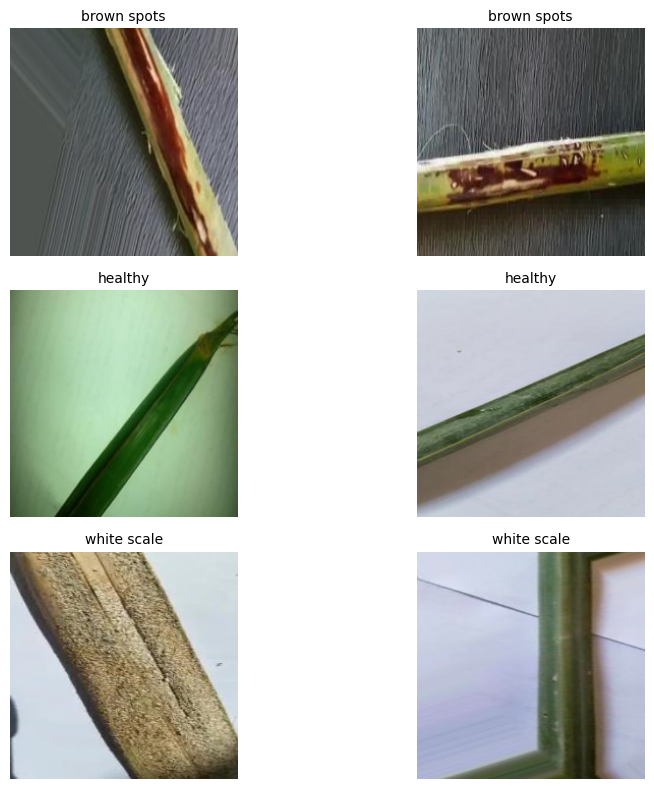

In [63]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

dataset_path = "C:\DatePalmDisease\Date Palm data"
processed_data = []
labels = []
img_size = (224, 224)

class_names = sorted(os.listdir(dataset_path))
class_mapping = {class_name: idx for idx, class_name in enumerate(class_names)}
print("\n Class Mapping:", class_mapping)

def load_and_preprocess_images():
    global processed_data, labels
    processed_data = []
    labels = []
    
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        label = class_mapping[class_name]  

        for img_name in tqdm(os.listdir(class_path), desc=f"Processing {class_name}"):
            img_path = os.path.join(class_path, img_name)
            try:
               
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                img = cv2.resize(img, img_size)
                img = img / 255.0  

                processed_data.append(img)
                labels.append(label)

            except Exception as e:
                print(f" Error processing {img_name}: {e}")

load_and_preprocess_images()

X_data = np.array(processed_data)
y_labels = np.array(labels)

np.save("C:/DatePalmDisease/X_CNN.npy", X_data)
np.save("C:/DatePalmDisease/y_CNN.npy", y_labels)

print(f" Processed Dataset Shape: {X_data.shape}, Labels Shape: {y_labels.shape}")

unique, counts = np.unique(y_labels, return_counts=True)
class_counts = {key: int(value) for key, value in zip(unique, counts)}

print("\n Class Distribution:", {class_names[k]: v for k, v in class_counts.items()})

def display_sample_images(num_images_per_class=2):
    fig, axes = plt.subplots(len(class_names), num_images_per_class, figsize=(10, 8))

    for i, class_label in enumerate(class_names):
        class_indices = np.where(y_labels == class_mapping[class_label])[0]
        random_samples = np.random.choice(class_indices, num_images_per_class, replace=False)
        
        for j, idx in enumerate(random_samples):
            axes[i, j].imshow(X_data[idx])
            axes[i, j].axis("off")
            axes[i, j].set_title(class_label, fontsize=10)

    plt.tight_layout()
    plt.show()

display_sample_images()


In [3]:
from tensorflow.keras.applications import  MobileNetV2, InceptionV3, DenseNet121,ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

def build_cnn_model(base_model_name):
    if base_model_name == "ResNet50":
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    elif base_model_name == "MobileNetV2":
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    elif base_model_name == "DenseNet121":
        base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    elif base_model_name == "InceptionV3":
        base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    else:
        raise ValueError("Invalid CNN model name")

    base_model.trainable = False  

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    output_layer = Dense(3, activation='softmax')(x)  

    model = Model(inputs=base_model.input, outputs=output_layer)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

model_ResNet50 = build_cnn_model("ResNet50")  
model_mobilenet = build_cnn_model("MobileNetV2")
model_densenet = build_cnn_model("DenseNet121")
model_inceptionv3 = build_cnn_model("InceptionV3")

print("\nResNet50 Model Summary:")
model_ResNet50.summary()  # Fixed name
print("\nMobileNetV2 Model Summary:")
model_mobilenet.summary()
print("\nDenseNet121 Model Summary:")
model_densenet.summary()
print("\nInceptionV3 Model Summary:")
model_inceptionv3.summary()



ResNet50 Model Summary:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 24,638,339 (93.99 MB)

 Trainable params: 1,050,627 (4.01 MB)

...

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_94 (Conv2D)            │ (None, 111, 111, 32)      │             864 │ input_layer_7[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_94        │ (None, 111, 111, 32)      │              96 │ conv2d_94[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_94 (Activation)    │ (None, 111, 111, 32)      │               0 │ batch_normalization_94[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_95 (Conv2D)            │ (None, 109, 109, 32)      │           9,216 │ activation_94[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_95        │ (None, 109, 109, 32)      │              96 │ conv2d_95[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_95 (Activation)    │ (None, 109, 109, 32)      │               0 │ batch_normalization_95[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_96 (Conv2D)            │ (None, 109, 109, 64)      │          18,432 │ activation_95[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_96        │ (None, 109, 109, 64)      │             192 │ conv2d_96[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_96 (Activation)    │ (None, 109, 109, 64)      │               0 │ batch_normalization_96[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_4               │ (None, 54, 54, 64)        │               0 │ activation_96[0][0]        │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_97 (Conv2D)            │ (None, 54, 54, 80)        │           5,120 │ max_pooling2d_4[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_97        │ (None, 54, 54, 80)        │             240 │ conv2d_97[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_97 (Activation)    │ (None, 54, 54, 80)        │               0 │ batch_normalization_97[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_98 (Conv2D)            │ (None, 52, 52, 192)       │         138,24

 Total params: 22,853,411 (87.18 MB)

 Trainable params: 1,050,627 (4.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    r"C:\DatePalmDisease\Split_Data\train",  
    target_size=(224, 224),  
    batch_size=32,  
    class_mode="categorical"  
)

test_generator = test_datagen.flow_from_directory(
    r"C:\DatePalmDisease\Split_Data\test",  
    target_size=(224, 224),  
    batch_size=32,  
    class_mode="categorical"  
)

num_classes = train_generator.num_classes


Found 2865 images belonging to 3 classes.
Found 717 images belonging to 3 classes.


In [1]:
#ResNet50
import os
import numpy as np
import tensorflow as tf
import pickle
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
import warnings
import absl

os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=2"
tf.config.optimizer.set_jit("autoclustering")

absl.logging.set_verbosity(absl.logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)

train_dir = r"C:\DatePalmDisease\Split_Data\train"
val_dir = r"C:\DatePalmDisease\Split_Data\test"
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,  # Increased rotation  
    width_shift_range=0.3,  
    height_shift_range=0.3,  
    shear_range=0.35,  # Increased  
    zoom_range=0.5,  # Increased  
    brightness_range=[0.5, 1.5],  # More variation  
    horizontal_flip=True,  
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=32, class_mode="categorical", shuffle=True
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=32, class_mode="categorical", shuffle=False
)

class_labels = np.unique(train_generator.classes)
class_weights = compute_class_weight("balanced", classes=class_labels, y=train_generator.classes)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

class_weights_dict[0] *= 0.85  # Reduce weight for Brown Spots slightly
class_weights_dict[1] *= 1.1   # Increase weight for Healthy
class_weights_dict[2] *= 1.1   # Increase weight for White Scale


print("\nComputed Class Weights:", class_weights_dict)

save_dir = r"C:\DatePalmDisease\Trained_Models"
history_dir = r"C:\DatePalmDisease\Training_History"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(history_dir, exist_ok=True)

resnet_model_h5 = os.path.join(save_dir, "ResNet50_New.h5")
resnet_history_pkl = os.path.join(history_dir, "ResNet50_History_New.pkl")

base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers[:80]:  
    layer.trainable = False  

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)  
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(train_generator.num_classes, activation="softmax")(x)  

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=Adam(learning_rate=5e-5),  
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.15),  
    metrics=["accuracy"]
)

lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=1, verbose=1, min_lr=1e-7)
early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1)

print("\nTraining ResNet50 with Class Weights...")
history = model.fit(
    train_generator,  
    validation_data=val_generator,  
    epochs=25,  
    class_weight=class_weights_dict,  
    callbacks=[lr_scheduler, early_stopping],  
    verbose=1  
)

model.save(resnet_model_h5)
print(f"\nResNet50 model saved successfully at: {resnet_model_h5}")

with open(resnet_history_pkl, "wb") as f:
    pickle.dump(history.history, f)

print(f"\nResNet50 training history saved successfully at: {resnet_history_pkl}")


Found 2865 images belonging to 3 classes.
Found 717 images belonging to 3 classes.

Computed Class Weights: {0: np.float64(1.0202991452991452), 1: np.float64(0.9927234927234927), 2: np.float64(0.9875904860392968)}

Training ResNet50 with Class Weights...
Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 841s 8s/step - accuracy: 0.3579 - loss: 1.2824 - val_accuracy: 0.3250 - val_loss: 1.1186 - learning_rate: 5.0000e-05
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 754s 8s/step - accuracy: 0.5498 - loss: 0.9327 - val_accuracy: 0.4881 - val_loss: 1.0398 - learning_rate: 5.0000e-05
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 759s 8s/step - accuracy: 0.5913 - loss: 0.8636 - val_accuracy: 0.4268 - val_loss: 1.0409 - learning_rate: 5.0000e-05
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 750s 8s/step - accuracy: 0.6154 - loss: 0.8477 - val_accuracy: 0.6067 - val_loss: 0.8646 - learning_rate: 5.0000e-05
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 705s 8s/step - accuracy: 0.6298 - loss: 0.8205 - val_accuracy: 0.5802 - val_loss: 0.982

In [1]:
#MobileNetV2
import os
import numpy as np
import tensorflow as tf
import pickle
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
import warnings
import absl

# Enable XLA JIT (Best for TPUs & High-end GPUs)
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=2"

# Enable XLA Autoclustering (Optimizes Execution Graph)
tf.config.optimizer.set_jit("autoclustering") 

absl.logging.set_verbosity(absl.logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)

train_dir = r"C:\DatePalmDisease\Split_Data\train"
val_dir = r"C:\DatePalmDisease\Split_Data\test"  
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=32, class_mode="categorical", shuffle=True
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=32, class_mode="categorical", shuffle=False
)

class_labels = np.unique(train_generator.classes)
class_weights = compute_class_weight("balanced", classes=class_labels, y=train_generator.classes)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

print("\n Computed Class Weights:", class_weights_dict)

save_dir = r"C:\DatePalmDisease\Trained_Models"
history_dir = r"C:\DatePalmDisease\Training_History"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(history_dir, exist_ok=True)

mobilenet_model_h5 = os.path.join(save_dir, "MobileNetV2_New.h5")
mobilenet_history_pkl = os.path.join(history_dir, "MobileNetV2_History_New.pkl")

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers[:-50]:  
    layer.trainable = False  

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x) 
output = Dense(train_generator.num_classes, activation="softmax")(x)  

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=Adam(learning_rate=5e-5),  
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  
    metrics=["accuracy"]
)

lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1, min_lr=1e-7)
early_stopping = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)

print("\n Training MobileNetV2 with Class Weights...")
history = model.fit(
    train_generator,  
    validation_data=val_generator,  
    epochs=15,  
    class_weight=class_weights_dict,  
    callbacks=[lr_scheduler, early_stopping],  
    verbose=1  
)

model.save(mobilenet_model_h5)
print(f"\n MobileNetV2 model saved successfully at: {mobilenet_model_h5}")

with open(mobilenet_history_pkl, "wb") as f:
    pickle.dump(history.history, f)

print(f"\n MobileNetV2 training history saved successfully at: {mobilenet_history_pkl}")


Found 2865 images belonging to 3 classes.
Found 717 images belonging to 3 classes.

 Computed Class Weights: {0: np.float64(1.0202991452991452), 1: np.float64(0.9927234927234927), 2: np.float64(0.9875904860392968)}

 Training MobileNetV2 with Class Weights...
Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 473s 4s/step - accuracy: 0.5279 - loss: 1.0099 - val_accuracy: 0.4547 - val_loss: 1.1222 - learning_rate: 5.0000e-05
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 395s 4s/step - accuracy: 0.8763 - loss: 0.5448 - val_accuracy: 0.4951 - val_loss: 1.3124 - learning_rate: 5.0000e-05
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 357s 4s/step - accuracy: 0.9259 - loss: 0.4673 - val_accuracy: 0.4979 - val_loss: 1.3190 - learning_rate: 5.0000e-05
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 387s 4s/step - accuracy: 0.9587 - loss: 0.4236 - val_accuracy: 0.6876 - val_loss: 0.8370 - learning_rate: 5.0000e-05
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.9629 - loss: 0.4104 - val_accuracy: 0.7517 - val_loss: 

In [5]:
#InceptionV3
import os
import numpy as np
import tensorflow as tf
import pickle
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import mixed_precision
import warnings
import absl

os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=2"
tf.config.optimizer.set_jit("autoclustering")


absl.logging.set_verbosity(absl.logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)

train_dir = r"C:\DatePalmDisease\Split_Data\train"
val_dir = r"C:\DatePalmDisease\Split_Data\test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=60, 
    width_shift_range=0.50,  
    height_shift_range=0.50,  
    shear_range=0.50,  
    zoom_range=0.70,  
    brightness_range=[0.2, 1.8],  
    horizontal_flip=True,  
    vertical_flip=True,  
    fill_mode="nearest"
)


val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(299, 299), batch_size=16, class_mode="categorical", shuffle=True
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(299, 299), batch_size=16, class_mode="categorical", shuffle=False
)


class_labels = np.unique(train_generator.classes)
class_weights = compute_class_weight("balanced", classes=class_labels, y=train_generator.classes)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
print("\nComputed Class Weights:", class_weights_dict)

class_weights_dict[0] *= 0.8
class_weights_dict[1] *= 1.1  
class_weights_dict[2] *= 1.1 


save_dir = r"C:\DatePalmDisease\Trained_Models"
history_dir = r"C:\DatePalmDisease\Training_History"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(history_dir, exist_ok=True)

inception_model_h5 = os.path.join(save_dir, "InceptionV3_New.h5")
inception_history_pkl = os.path.join(history_dir, "InceptionV3_History_New.pkl")

base_model = InceptionV3(weights="imagenet", include_top=False, input_shape=(299, 299, 3))

for layer in base_model.layers[:100]: 
    layer.trainable = False  
for layer in base_model.layers[120:]: 
    layer.trainable = True  


x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.9)(x)  # Increased from 0.5
x = Dense(256, activation="relu")(x)
x = Dropout(0.7)(x)  # Increased from 0.4
output = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=Adam(learning_rate=1e-5), 
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),  
    metrics=["accuracy"]
)
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, verbose=1, min_lr=1e-7)
early_stopping = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1)

print("\nTraining InceptionV3 ...")
history = model.fit(
    train_generator,  
    validation_data=val_generator,  
    epochs=20,
    class_weight=class_weights_dict,  
    callbacks=[lr_scheduler, early_stopping],  
    verbose=1  
)
model.save(inception_model_h5)
print(f"\nInceptionV3 model saved successfully at: {inception_model_h5}")
with open(inception_history_pkl, "wb") as f:
    pickle.dump(history.history, f)
print(f"\nInceptionV3 training history saved successfully at: {inception_history_pkl}")

Found 2865 images belonging to 3 classes.
Found 717 images belonging to 3 classes.

Computed Class Weights: {0: np.float64(1.0202991452991452), 1: np.float64(0.9927234927234927), 2: np.float64(0.9875904860392968)}

Training InceptionV3 ...
Epoch 1/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 1024s 5s/step - accuracy: 0.3185 - loss: 2.2100 - val_accuracy: 0.6123 - val_loss: 1.0079 - learning_rate: 1.0000e-05
Epoch 2/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 927s 5s/step - accuracy: 0.3415 - loss: 1.6182 - val_accuracy: 0.6792 - val_loss: 0.9719 - learning_rate: 1.0000e-05
Epoch 3/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 929s 5s/step - accuracy: 0.3590 - loss: 1.2758 - val_accuracy: 0.7420 - val_loss: 0.9577 - learning_rate: 1.0000e-05
Epoch 4/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 900s 5s/step - accuracy: 0.3991 - loss: 1.1491 - val_accuracy: 0.7573 - val_loss: 0.9445 - learning_rate: 1.0000e-05
Epoch 5/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 862s 5s/step - accuracy: 0.4340 - loss: 1.0798 - val_accuracy: 0.7685 - val_loss: 0.9137 - 

In [1]:
#DenseNet121
import os
import numpy as np
import tensorflow as tf
import pickle
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
import warnings
import absl

os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=2"
tf.config.optimizer.set_jit("autoclustering")

absl.logging.set_verbosity(absl.logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)

train_dir = r"C:\DatePalmDisease\Split_Data\train"
val_dir = r"C:\DatePalmDisease\Split_Data\test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=70,   
    width_shift_range=0.6,
    height_shift_range=0.6,
    shear_range=0.6,  
    zoom_range=0.8, 
    brightness_range=[0.1, 1.9], 
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)
val_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(299, 299), batch_size=32, class_mode="categorical", shuffle=True
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(299, 299), batch_size=32, class_mode="categorical", shuffle=False
)

class_labels = np.unique(train_generator.classes)
class_weights = compute_class_weight("balanced", classes=class_labels, y=train_generator.classes)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
print("\nOriginal Class Weights:", class_weights_dict)

class_weights_dict[0] *= 0.6  
class_weights_dict[1] *= 1.0  
class_weights_dict[2] *= 0.9   
print("Updated Class Weights:", class_weights_dict)

save_dir = r"C:\DatePalmDisease\Trained_Models"
history_dir = r"C:\DatePalmDisease\Training_History"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(history_dir, exist_ok=True)

densenet_model_h5 = os.path.join(save_dir, "DenseNet121_New.h5")
densenet_history_pkl = os.path.join(history_dir, "DenseNet121_History_New.pkl")

base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(299, 299, 3))

for layer in base_model.layers[:150]:
    layer.trainable = False
for layer in base_model.layers[150:]:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.6)(x)  
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x) 
output = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1, min_lr=1e-7)
early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1)

print("\nTraining DenseNet121...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)
model.save(densenet_model_h5)
print(f"\n DenseNet121 model saved at: {densenet_model_h5}")
f
with open(densenet_history_pkl, "wb") as f: 
    pickle.dump(history.history, f)
print(f" Training history saved at: {densenet_history_pkl}")

Found 2865 images belonging to 3 classes.
Found 717 images belonging to 3 classes.

Original Class Weights: {0: np.float64(1.0202991452991452), 1: np.float64(0.9927234927234927), 2: np.float64(0.9875904860392968)}
Updated Class Weights: {0: np.float64(0.6121794871794871), 1: np.float64(0.9927234927234927), 2: np.float64(0.8888314374353671)}

Training DenseNet121...
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1148s 11s/step - accuracy: 0.3908 - loss: 1.1822 - val_accuracy: 0.8354 - val_loss: 0.6196 - learning_rate: 5.0000e-05
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 995s 11s/step - accuracy: 0.6043 - loss: 0.7830 - val_accuracy: 0.9177 - val_loss: 0.4745 - learning_rate: 5.0000e-05
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 922s 10s/step - accuracy: 0.6968 - loss: 0.6604 - val_accuracy: 0.9442 - val_loss: 0.4408 - learning_rate: 5.0000e-05
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 974s 11s/step - accuracy: 0.7771 - loss: 0.5736 - val_accuracy: 0.9609 - val_loss: 0.4013 - learning_rate: 5.0000e-05
Epoch 5

Found 717 images belonging to 3 classes.

 Evaluating Model on Validation Set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step

 Classification Report:
              precision    recall  f1-score   support

 brown spots       1.00      1.00      1.00       234
     healthy       0.97      0.98      0.98       241
 white scale       0.98      0.97      0.98       242

    accuracy                           0.98       717
   macro avg       0.98      0.98      0.98       717
weighted avg       0.98      0.98      0.98       717



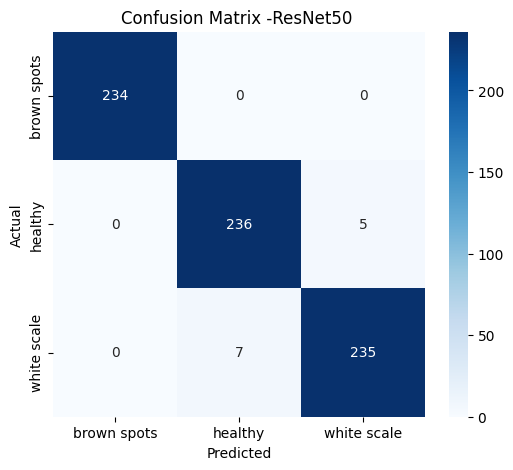

In [3]:
import os
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

mobilenet_model_h5 = r"C:\DatePalmDisease\Trained_Models\ResNet50_New.h5"
model = tf.keras.models.load_model(mobilenet_model_h5)

val_dir = r"C:\DatePalmDisease\Split_Data\test"
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=32, class_mode="categorical", shuffle=False
)

print("\n Evaluating Model on Validation Set...")
val_preds = model.predict(val_generator)
y_pred_classes = np.argmax(val_preds, axis=1)
y_true = val_generator.classes

print("\n Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=val_generator.class_indices.keys(), yticklabels=val_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix -ResNet50 ")
plt.show()


Found 717 images belonging to 3 classes.

 Evaluating Model on Validation Set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 949ms/step

 Classification Report:
              precision    recall  f1-score   support

 brown spots       1.00      0.99      0.99       234
     healthy       0.99      1.00      0.99       241
 white scale       1.00      1.00      1.00       242

    accuracy                           0.99       717
   macro avg       0.99      0.99      0.99       717
weighted avg       0.99      0.99      0.99       717



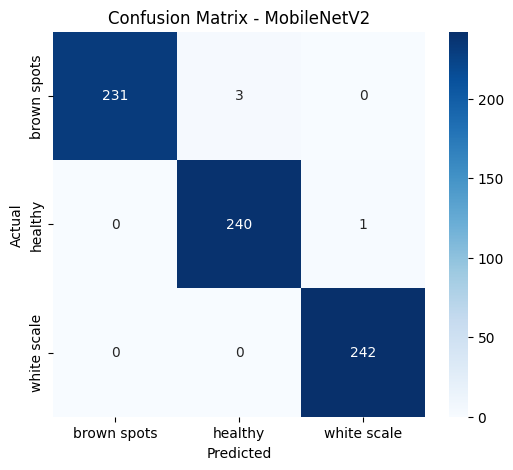

In [17]:
#import os
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

mobilenet_model_h5 = r"C:\DatePalmDisease\Trained_Models\MobileNetV2_New.h5"
model = tf.keras.models.load_model(mobilenet_model_h5)

val_dir = r"C:\DatePalmDisease\Split_Data\test"
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=32, class_mode="categorical", shuffle=False
)

print("\n Evaluating Model on Validation Set...")
val_preds = model.predict(val_generator)
y_pred_classes = np.argmax(val_preds, axis=1)
y_true = val_generator.classes

print("\n Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=val_generator.class_indices.keys(), yticklabels=val_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MobileNetV2")
plt.show()


Found 717 images belonging to 3 classes.

 Evaluating Model on Validation Set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 97s 4s/step

 Classification Report:
              precision    recall  f1-score   support

 brown spots       1.00      1.00      1.00       234
     healthy       0.96      0.95      0.96       241
 white scale       0.95      0.96      0.95       242

    accuracy                           0.97       717
   macro avg       0.97      0.97      0.97       717
weighted avg       0.97      0.97      0.97       717



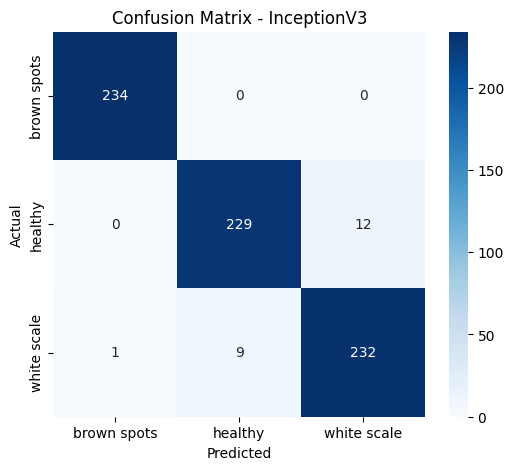

In [7]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import warnings
import absl

absl.logging.set_verbosity(absl.logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)

InceptionV3_model_h5 = r"C:\DatePalmDisease\Trained_Models\InceptionV3_New.h5"
model = tf.keras.models.load_model(InceptionV3_model_h5)

val_dir = r"C:\DatePalmDisease\Split_Data\test"
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(299, 299), batch_size=32, class_mode="categorical", shuffle=False
)

print("\n Evaluating Model on Validation Set...")
val_preds = model.predict(val_generator)
y_pred_classes = np.argmax(val_preds, axis=1)
y_true = val_generator.classes

print("\n Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=val_generator.class_indices.keys(), yticklabels=val_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - InceptionV3")
plt.show()


Found 717 images belonging to 3 classes.

 Evaluating Model on Validation Set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 154s 6s/step

 Classification Report:
              precision    recall  f1-score   support

 brown spots       1.00      1.00      1.00       234
     healthy       0.97      0.99      0.98       241
 white scale       0.99      0.97      0.98       242

    accuracy                           0.99       717
   macro avg       0.99      0.99      0.99       717
weighted avg       0.99      0.99      0.99       717



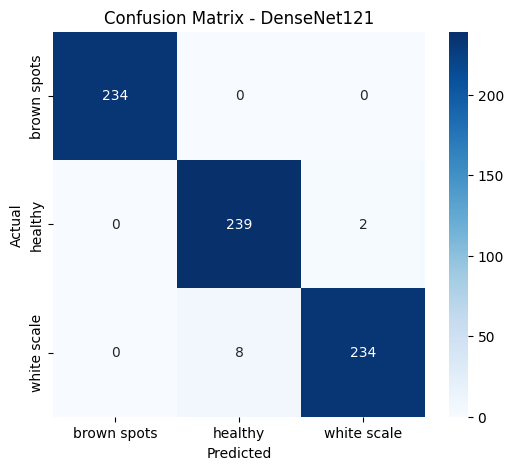

In [5]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import warnings
import absl

absl.logging.set_verbosity(absl.logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)

DenseNet121_model_h5 = r"C:\DatePalmDisease\Trained_Models\DenseNet121_New.h5"
model = tf.keras.models.load_model(DenseNet121_model_h5)

val_dir = r"C:\DatePalmDisease\Split_Data\test"
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(299, 299), batch_size=32, class_mode="categorical", shuffle=False
)

print("\n Evaluating Model on Validation Set...")
val_preds = model.predict(val_generator)
y_pred_classes = np.argmax(val_preds, axis=1)
y_true = val_generator.classes

print("\n Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=val_generator.class_indices.keys(), yticklabels=val_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DenseNet121")
plt.show()


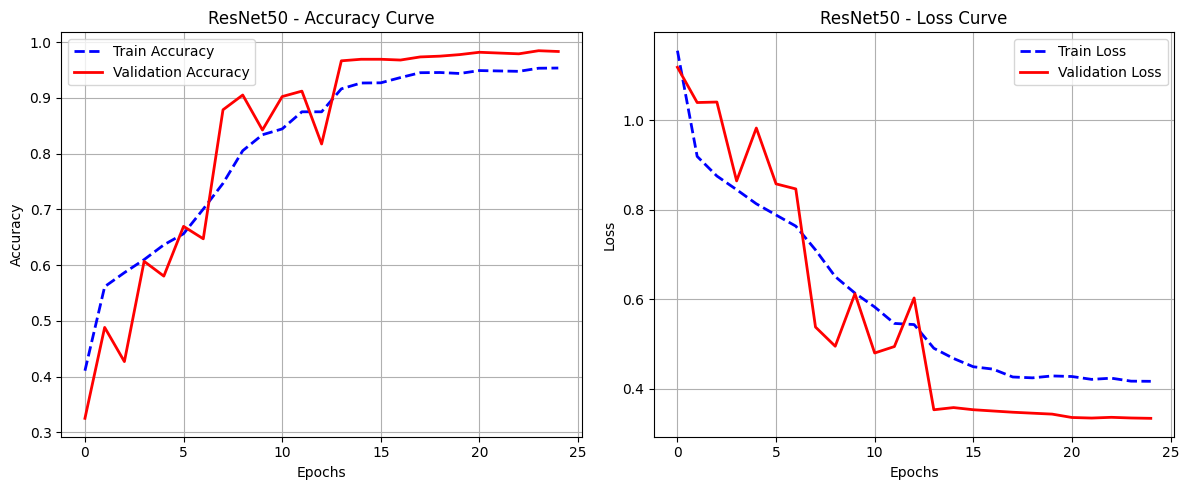

In [5]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
# Load the history object
with open(r"C:\DatePalmDisease\Training_History\ResNet50_History_New.pkl", "rb") as f:
    history_ResNet50 = pickle.load(f)

# If it is a dictionary, you can use it directly:
history_dict = history_ResNet50  # Directly use the dictionary

# Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dict["accuracy"], label="Train Accuracy", color="blue", linestyle="dashed", linewidth=2)
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy", color="red", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ResNet50 - Accuracy Curve")
plt.legend()
plt.grid()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_dict["loss"], label="Train Loss", color="blue", linestyle="dashed", linewidth=2)
plt.plot(history_dict["val_loss"], label="Validation Loss", color="red", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ResNet50 - Loss Curve")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


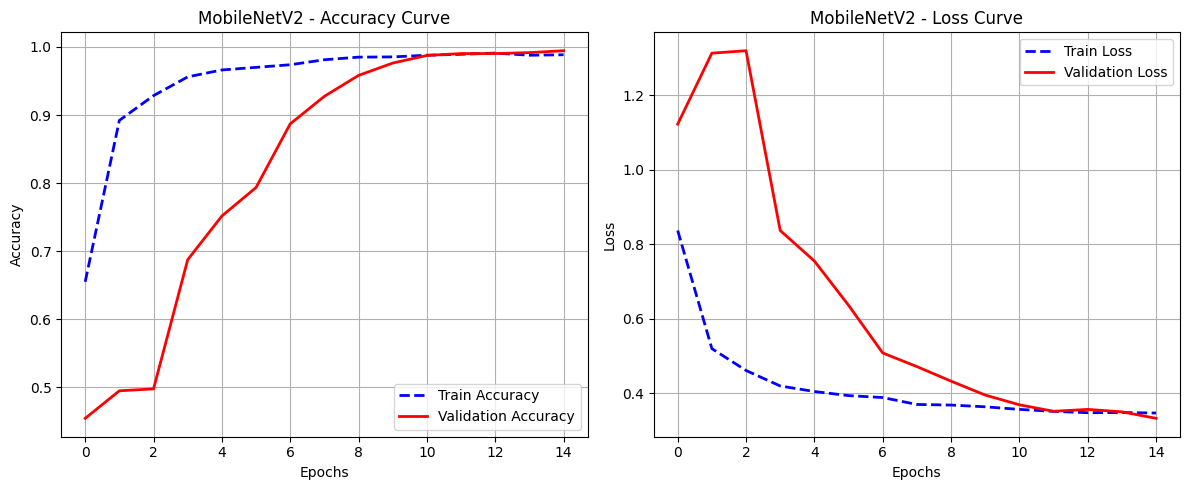

In [7]:
#MobileNetV2
import numpy as np
import pickle
import matplotlib.pyplot as plt

with open("C:\DatePalmDisease\Training_History\MobileNetV2_History_New.pkl", "rb") as f:
    history_MobileNetV2 = pickle.load(f)  

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_MobileNetV2["accuracy"], label="Train Accuracy", color="blue", linestyle="dashed", linewidth=2)
plt.plot(history_MobileNetV2["val_accuracy"], label="Validation Accuracy", color="red", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Accuracy Curve")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history_MobileNetV2["loss"], label="Train Loss", color="blue", linestyle="dashed", linewidth=2)
plt.plot(history_MobileNetV2["val_loss"], label="Validation Loss", color="red", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Loss Curve")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


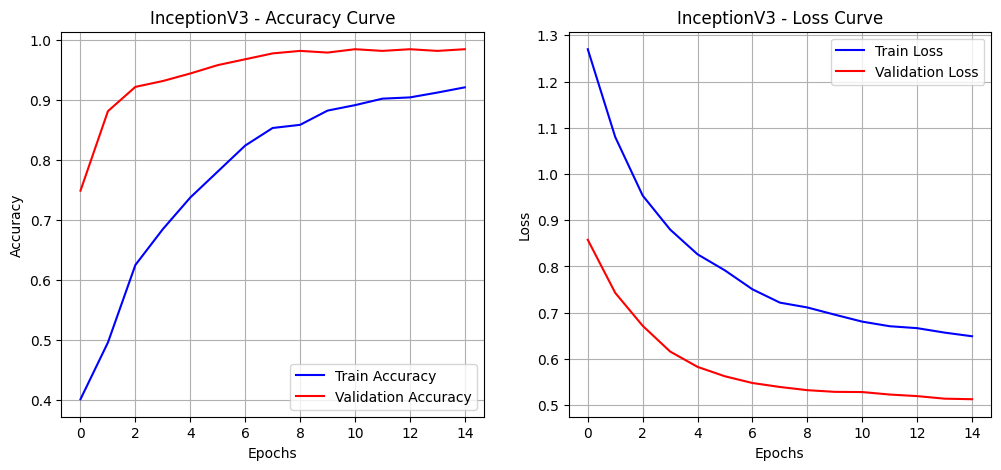

In [6]:
#InceptionV3 
import numpy as np
import pickle
import matplotlib.pyplot as plt

with open("C:\DatePalmDisease\Training_History\InceptionV3_History_New.pkl", "rb") as f:
    history_InceptionV3 = pickle.load(f)  

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_InceptionV3['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_InceptionV3['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("InceptionV3 - Accuracy Curve")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history_InceptionV3['loss'], label='Train Loss', color='blue')
plt.plot(history_InceptionV3['val_loss'], label='Validation Loss', color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("InceptionV3 - Loss Curve")
plt.legend()
plt.grid()
plt.show()


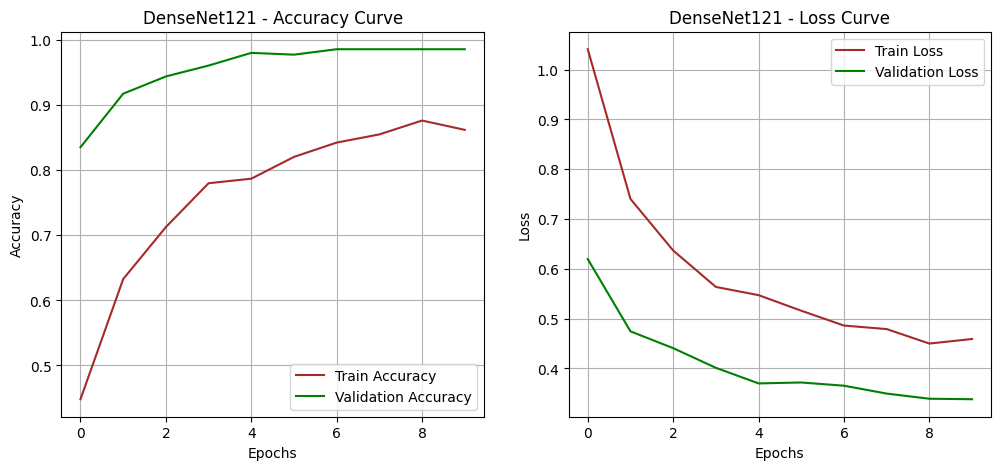

In [7]:
# DenseNet121
import numpy as np
import pickle
import matplotlib.pyplot as plt

with open("C:\DatePalmDisease\Training_History\DenseNet121_History_New.pkl", "rb") as f:
    history_DenseNet121 = pickle.load(f)  

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_DenseNet121['accuracy'], label="Train Accuracy", color='brown')
plt.plot(history_DenseNet121['val_accuracy'], label="Validation Accuracy", color='green')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("DenseNet121 - Accuracy Curve")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history_DenseNet121['loss'], label="Train Loss", color='brown')
plt.plot(history_DenseNet121['val_loss'], label="Validation Loss", color='green')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("DenseNet121 - Loss Curve")
plt.legend()
plt.grid()

plt.show()



 Processing ResNet50...
Found 717 images belonging to 3 classes.

 Processing MobileNetV2...
Found 717 images belonging to 3 classes.

 Processing InceptionV3...
Found 717 images belonging to 3 classes.

 Processing DenseNet121...
Found 717 images belonging to 3 classes.

 Metrics CSV saved at: C:\DatePalmDisease\CNN_Model_Metrics.csv
DenseNet121 Classification Report saved at: C:\DatePalmDisease\CNN_Reports\DenseNet121_Classification_Report.csv


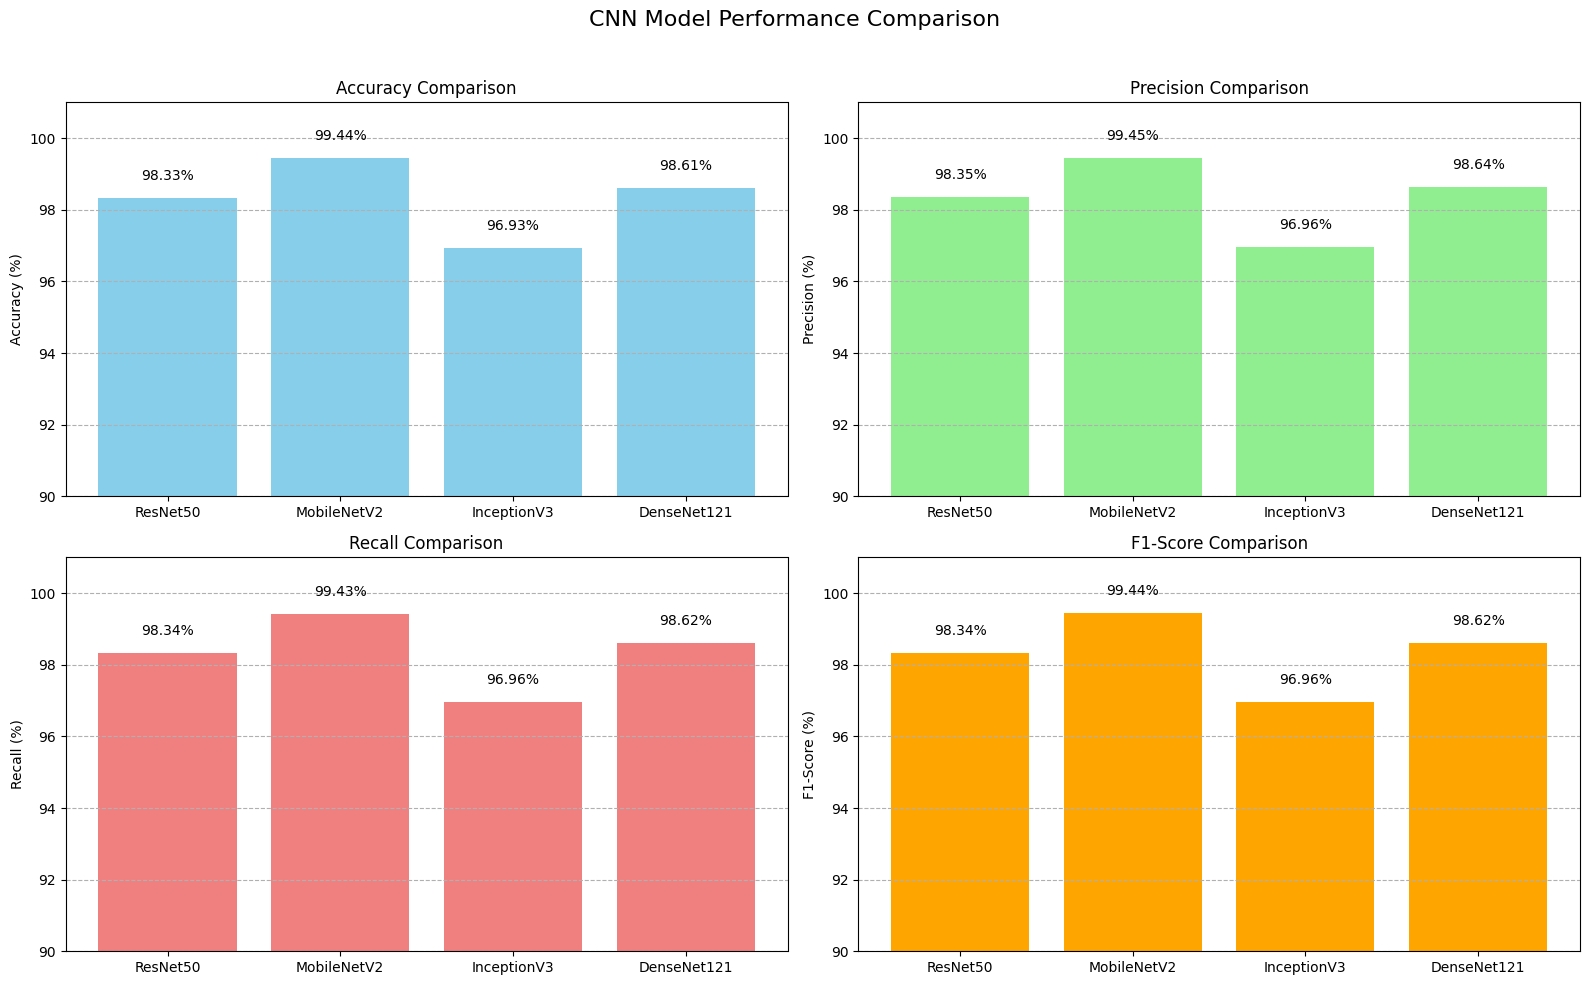

In [11]:
# 📦 Import required packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
import absl

absl.logging.set_verbosity(absl.logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)

model_paths = {
    "ResNet50": r"C:\DatePalmDisease\Trained_Models\ResNet50_New.h5",
    "MobileNetV2": r"C:\DatePalmDisease\Trained_Models\MobileNetV2_New.h5",
    "InceptionV3": r"C:\DatePalmDisease\Trained_Models\InceptionV3_New.h5",
    "DenseNet121": r"C:\DatePalmDisease\Trained_Models\DenseNet121_New.h5"
}

model_input_sizes = {
    "ResNet50": (224, 224),
    "MobileNetV2": (224, 224),
    "DenseNet121": (299, 299),
    "InceptionV3": (299, 299)
}

test_data_path = r"C:\DatePalmDisease\Split_Data\test"

batch_size = 32

metrics_dict = {}

for model_name, model_path in model_paths.items():
    print(f"\n Processing {model_name}...")

    model = load_model(model_path)

    img_size = model_input_sizes[model_name]
    
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(
        test_data_path,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    predictions = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    metrics_dict[model_name] = {
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    }

metrics_df = pd.DataFrame(metrics_dict).T

csv_path = r"C:\DatePalmDisease\CNN_Model_Metrics.csv"
metrics_df.to_csv(csv_path)
print("\n Metrics CSV saved at:", csv_path)

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Classification report
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()

# Save individual report for each model
report_csv_path = fr"C:\DatePalmDisease\CNN_Reports\{model_name}_Classification_Report.csv"
os.makedirs(os.path.dirname(report_csv_path), exist_ok=True)
report_df.to_csv(report_csv_path)
print(f"{model_name} Classification Report saved at:", report_csv_path)

# Plotting individual metric comparisons like the uploaded sample
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("CNN Model Performance Comparison", fontsize=16)

# Convert values to percentage for plotting
metrics_percent = metrics_df * 100

# Accuracy
axs[0, 0].bar(metrics_percent.index, metrics_percent['Accuracy'], color='skyblue')
axs[0, 0].set_title('Accuracy Comparison')
axs[0, 0].set_ylabel('Accuracy (%)')
for i, v in enumerate(metrics_percent['Accuracy']):
    axs[0, 0].text(i, v + 0.5, f"{v:.2f}%", ha='center')

# Precision
axs[0, 1].bar(metrics_percent.index, metrics_percent['Precision'], color='lightgreen')
axs[0, 1].set_title('Precision Comparison')
axs[0, 1].set_ylabel('Precision (%)')
for i, v in enumerate(metrics_percent['Precision']):
    axs[0, 1].text(i, v + 0.5, f"{v:.2f}%", ha='center')

# Recall
axs[1, 0].bar(metrics_percent.index, metrics_percent['Recall'], color='lightcoral')
axs[1, 0].set_title('Recall Comparison')
axs[1, 0].set_ylabel('Recall (%)')
for i, v in enumerate(metrics_percent['Recall']):
    axs[1, 0].text(i, v + 0.5, f"{v:.2f}%", ha='center')

# F1 Score
axs[1, 1].bar(metrics_percent.index, metrics_percent['F1-Score'], color='orange')
axs[1, 1].set_title('F1-Score Comparison')
axs[1, 1].set_ylabel('F1-Score (%)')
for i, v in enumerate(metrics_percent['F1-Score']):
    axs[1, 1].text(i, v + 0.5, f"{v:.2f}%", ha='center')

# Layout tweaks
for ax in axs.flat:
    ax.set_ylim(90, 101)
    ax.set_xticks(range(len(metrics_percent.index)))
    ax.set_xticklabels(metrics_percent.index)
    ax.grid(axis='y', linestyle='--')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


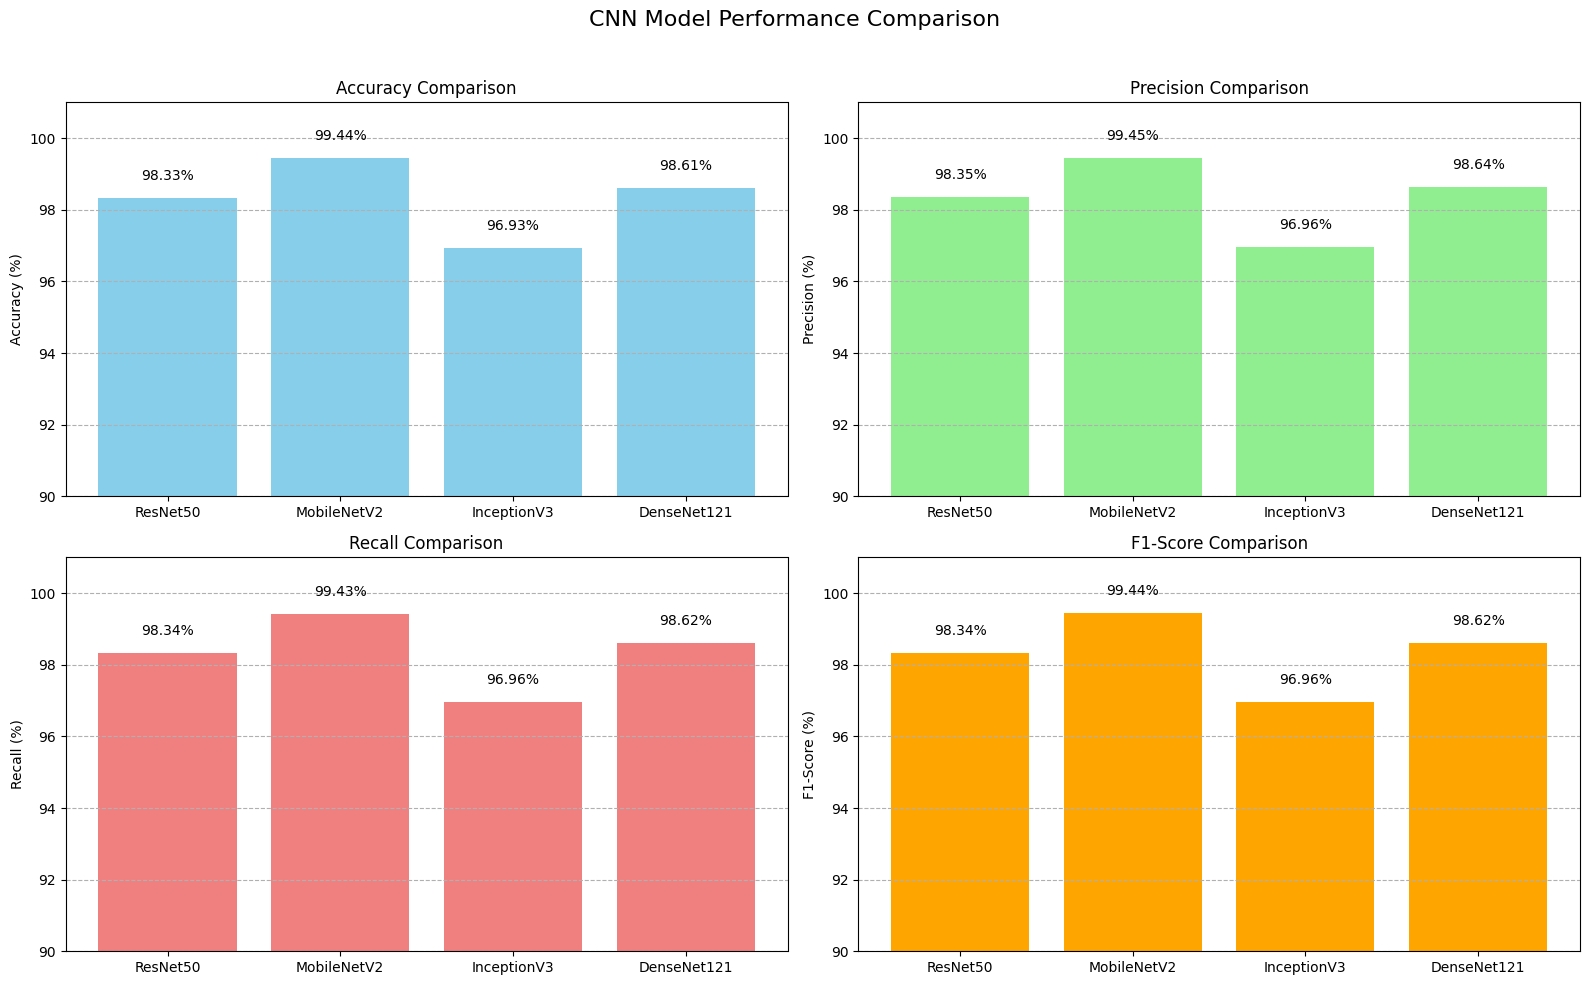

In [5]:
# Plotting individual metric comparisons like the uploaded sample
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("CNN Model Performance Comparison", fontsize=16)

# Convert values to percentage for plotting
metrics_percent = metrics_df * 100

# Accuracy
axs[0, 0].bar(metrics_percent.index, metrics_percent['Accuracy'], color='skyblue')
axs[0, 0].set_title('Accuracy Comparison')
axs[0, 0].set_ylabel('Accuracy (%)')
for i, v in enumerate(metrics_percent['Accuracy']):
    axs[0, 0].text(i, v + 0.5, f"{v:.2f}%", ha='center')

# Precision
axs[0, 1].bar(metrics_percent.index, metrics_percent['Precision'], color='lightgreen')
axs[0, 1].set_title('Precision Comparison')
axs[0, 1].set_ylabel('Precision (%)')
for i, v in enumerate(metrics_percent['Precision']):
    axs[0, 1].text(i, v + 0.5, f"{v:.2f}%", ha='center')

# Recall
axs[1, 0].bar(metrics_percent.index, metrics_percent['Recall'], color='lightcoral')
axs[1, 0].set_title('Recall Comparison')
axs[1, 0].set_ylabel('Recall (%)')
for i, v in enumerate(metrics_percent['Recall']):
    axs[1, 0].text(i, v + 0.5, f"{v:.2f}%", ha='center')

# F1 Score
axs[1, 1].bar(metrics_percent.index, metrics_percent['F1-Score'], color='orange')
axs[1, 1].set_title('F1-Score Comparison')
axs[1, 1].set_ylabel('F1-Score (%)')
for i, v in enumerate(metrics_percent['F1-Score']):
    axs[1, 1].text(i, v + 0.5, f"{v:.2f}%", ha='center')

# Layout tweaks
for ax in axs.flat:
    ax.set_ylim(90, 101)
    ax.set_xticks(range(len(metrics_percent.index)))
    ax.set_xticklabels(metrics_percent.index)
    ax.grid(axis='y', linestyle='--')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
